In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os

from maui_analysis.process_behavior import pull_fictrac_speed, pull_fictrac_timestamps, save_speed_data
from maui_analysis.data_alignment import *
from maui_codebook.visualizations import *
import xarray as xr
import glob
import scipy.cluster.hierarchy as shc

from scipy.interpolate import interp1d
def interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps):
    f = interp1d(walk_times, walk_speeds)
    speed_new = f(maui_vol_timestamps)
    return speed_new

def plot_zscored_activity(clusters_toplot, signal_xarray):
    fig, ax = plt.subplots(figsize=(20, len(clusters_toplot)))
    yshift = 1
    # n_lines = len(clusters_toplot)
    palette_colors = sns.color_palette("Blues", len(clusters_toplot))

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")

import matplotlib.colors as colors
def plot_spatial_location(clusters_toplot, cluster_2d_arr, brain_dimensions):
    fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(40, 40), constrained_layout=True)
    palette_colors = sns.color_palette("twilight", 25)
    cmap = ListedColormap(palette_colors)

    axes = axes.flatten()
    blank_brain = create_blank_brain(cluster_2d_arr)
    for cluster in clusters_toplot:
        identify_single_cluster(cluster_2d_arr, blank_brain, cluster)

    blank_brain_clusters = blank_brain.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])
    raw_brain_clusters = cluster_2d_arr.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])

    for idx in range(brain_dimensions[2]):
        ax = axes[idx]
        # ax.imshow(raw_brain_clusters[idx].T, cmap="gray_r", alpha=0.7)
        ax.imshow(blank_brain_clusters[idx].T, cmap=cmap, alpha=1)
        ax.set_title(f"Slice {idx}")

    for j in range(brain_dimensions[2], len(axes)):
        fig.delaxes(axes[j])

In [107]:

fly = '09'
win = '1'

In [108]:
path_to_voltage_csv = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/')[0]
voltage_csv = glob.glob(path_to_voltage_csv + '*VoltageRecording_001.csv')[0]
dat_file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10_GC8m_fly{fly}_win0{win}_trial01/*.dat')[0]
print(voltage_csv)
processed_path = '/Volumes/AhmedLab/princess/data/pIP10/processed'
experiment_path = glob.glob(processed_path + f'/pIP10_TSeries_*fly{fly}_win0{win}*')[0]

SLICES = 11
DIMENSIONS = [512,512,11]

/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001_Cycle00001_VoltageRecording_001.csv


1. Fly02Win01
- rois = [ [6,8], [6,14], [6,11], [6,19], [7,2], [7,10], [8,9],  [8,14], [9,6]]
2. Fly03Win01
- rois = [ [4,4], [4,16], [5,18], [6,1],  [7,4]]
3. Fly03Win02
- rois =
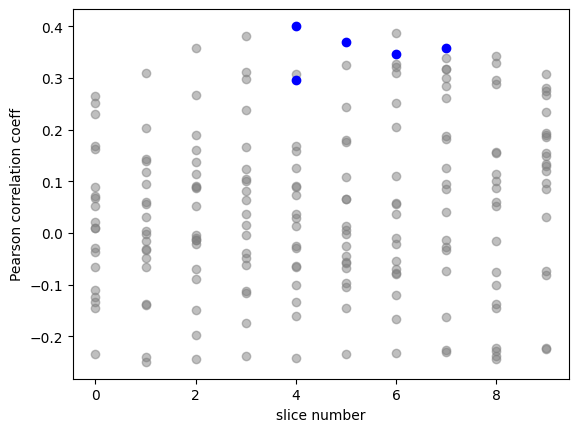

In [109]:

hf_path = f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/synced_data.h5'
if not glob.glob(hf_path):
    save_path = glob.glob(os.path.dirname(hf_path))[0]
    save_speed_data(dat_file, voltage_csv, save_path=save_path)
    # # takes ~2-3 minutes
synced_data_hf = glob.glob(hf_path)[0]

In [110]:
file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/20_supervoxels.h5')[0]
with h5py.File(file, "r") as f:
    print(f.keys())

<KeysViewHDF5 ['labels', 'signals']>


In [111]:
with h5py.File(file, "r") as f:
    print(f.keys())
    cluster_labels = f["labels"][...]
    signal = f["signal"][...]
    shift = f["shifted_signals"][...]


<KeysViewHDF5 ['labels', 'signals']>


KeyError: "Unable to synchronously open object (object 'signal' doesn't exist)"

In [13]:
# process fictrac data
beh_speed = pull_fictrac_speed(dat_file)
beh_timestamps = pull_fictrac_timestamps(voltage_csv, beh_speed)

# align to scope data
maui_vol_timestamps = align_scopetimes_to_behaviortimes(path_to_voltage_csv, synced_data_hf, SLICES)
walk_times, walk_speeds = open_processed_behavior_data(synced_data_hf)

synced_walk_speeds = interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps)

signal = signal[...,:len(maui_vol_timestamps)]
shift = shift[...,:len(maui_vol_timestamps)]


signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': maui_vol_timestamps/1000}
)
sh_signal_xr = xr.DataArray(
    data=shift,
    dims=['zposs', 'roi', 'time'],
    coords={'time': maui_vol_timestamps/1000}
)

behav_xr = xr.DataArray(
    data = synced_walk_speeds,
    dims = ['time'],
    coords = {'time': maui_vol_timestamps/1000}
)

<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>


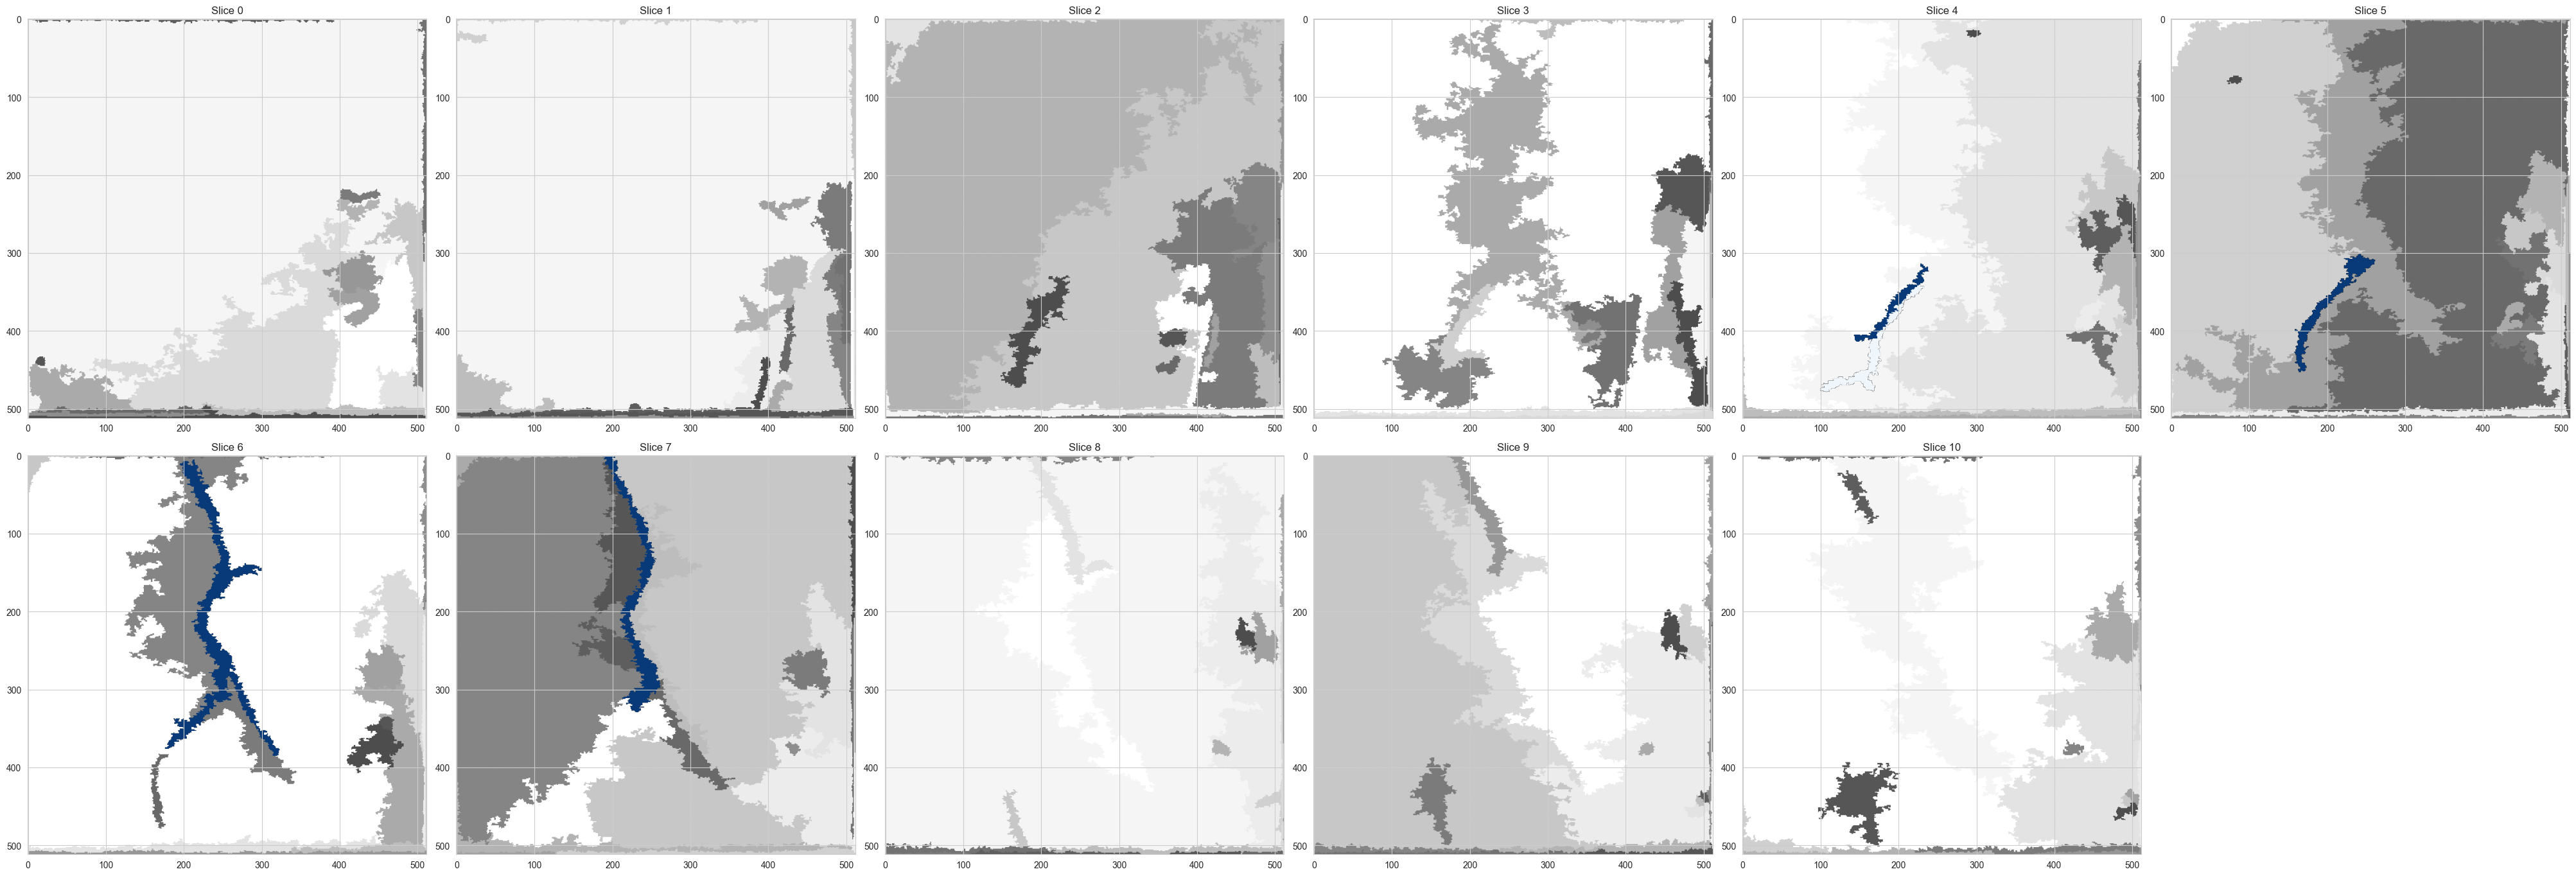

In [21]:
# # rois = [[6,0], [6,11], [6,12], [7,9], [7,11], [7,10],[8,5], [8,3], [8,4] ]
# rois = [[4,4], [4,16], [5,18], [6,1], [7,4]]
# # fig = plot_zscored_activity(rois, signal_xr)
# # plt.figure(figsize=(20, 3))
# # plt.plot(maui_vol_timestamps/1000,synced_walk_speeds, color = 'k')
# fig2 = plot_spatial_location(rois, cluster_labels, DIMENSIONS)

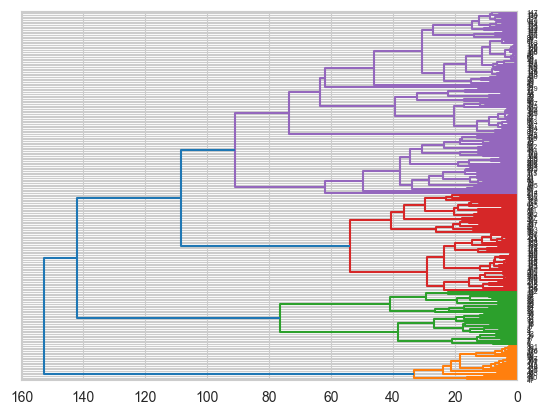

In [17]:
to_cluster = signal_xr.stack(supervoxel=['zposs','roi']).T
Z = shc.linkage(to_cluster, method='ward')
# NCLUSTERS = 50
# dn = shc.dendrogram(Z, p=NCLUSTERS, truncate_mode='lastp')
# clust_labels = shc.fcluster(Z, NCLUSTERS, criterion='maxclust')
dn = shc.dendrogram(Z, orientation='left')

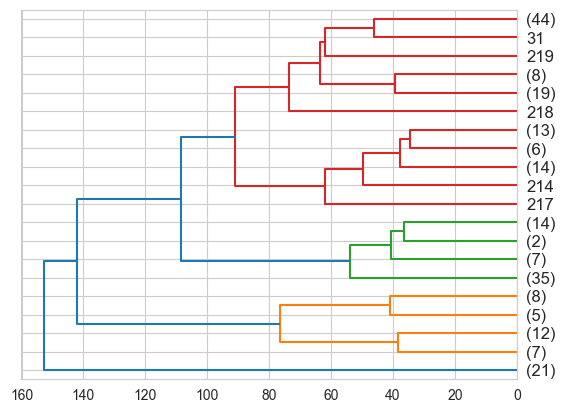

In [33]:
# assign cluster to each supervoxel

# group by
nclusters = 20
_ = shc.dendrogram(Z, orientation='left', truncate_mode='lastp', p=nclusters)
clust_labels = shc.fcluster(Z, nclusters, criterion='maxclust')

# dff = dff.assign_coords(cluster =('supervoxel', clust_labels)).set_index(supervoxel='cluster', append=True)

# adds in the cluster number as a new coordinate - each supervoxel has a designated cluster
grouped_sv = to_cluster.assign_coords(cluster = ('supervoxel', clust_labels)).set_index(supervoxel='cluster', append=True)

In [34]:
# on spatial maps, replace supervoxel id with cluster value

clusters_spatial = np.empty(cluster_labels.shape, dtype=int)
print(clusters_spatial.shape)
for z,px_list in enumerate(cluster_labels):
    # find cluster value
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for px, sv in enumerate(px_list):
        clusters_spatial[z,px] = values[sv]

(11, 262144)


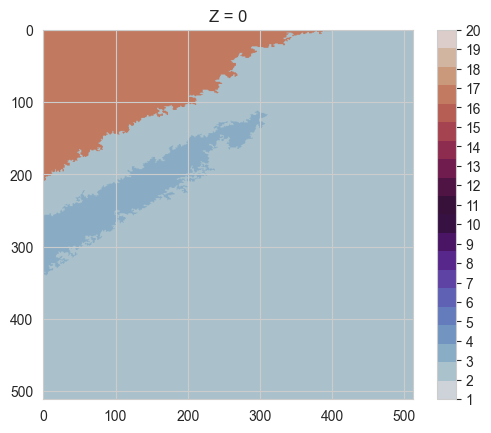

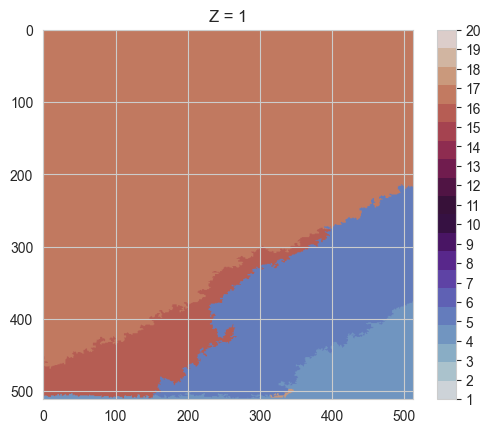

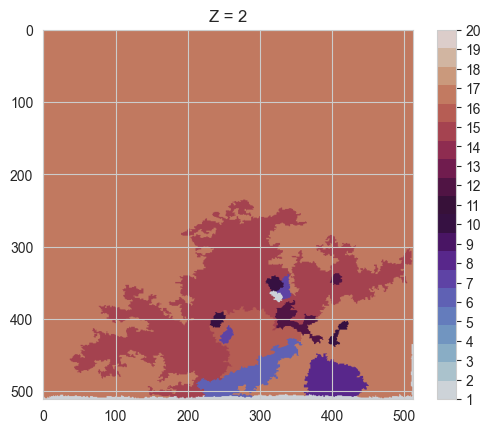

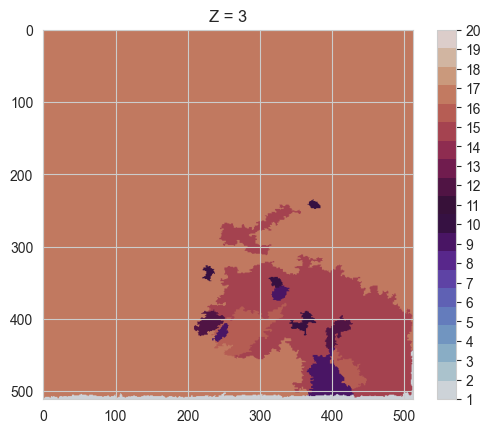

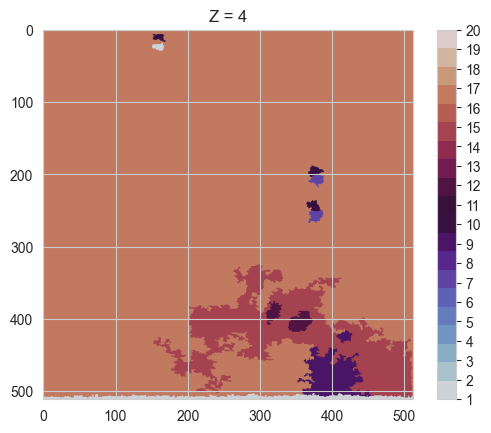

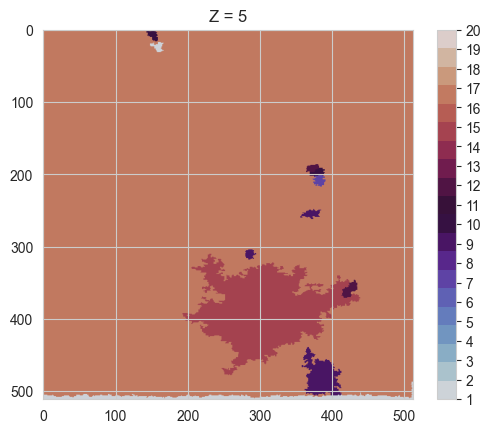

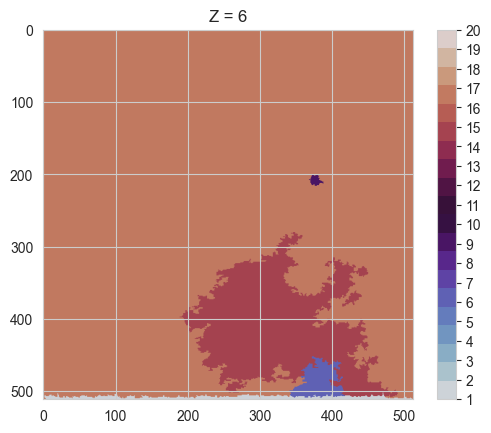

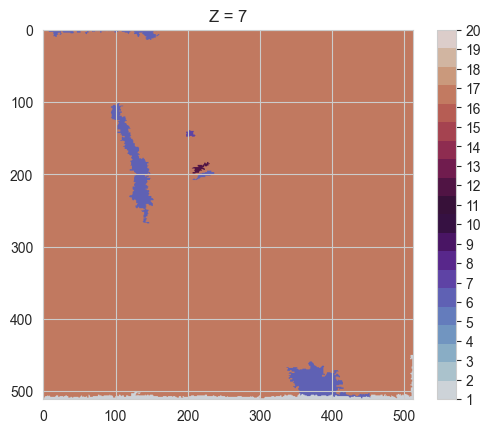

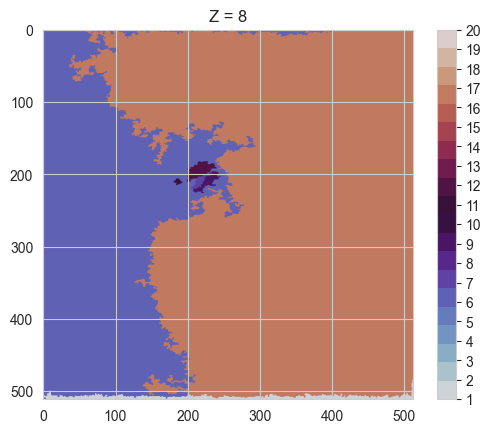

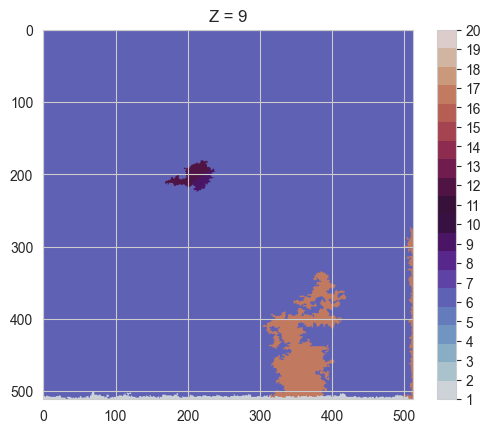

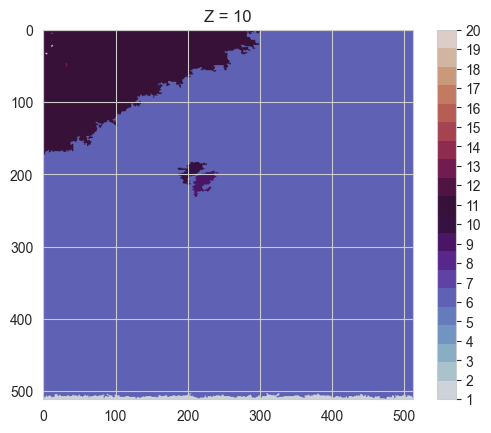

In [35]:
norm = colors.Normalize(vmin=1, vmax=nclusters)
palette_colors = sns.color_palette("twilight", nclusters)
cmap = ListedColormap(palette_colors)
#
for z in range(11):
    plt.figure()
    image = np.reshape(clusters_spatial[z],[512,512])
    plt.imshow(image.T, cmap=cmap, norm=norm)
    plt.colorbar(ticks=np.arange(1,nclusters+1))
    plt.title (f'Z = {z}')

[[7, 2], [7, 6], [7, 12], [7, 14], [7, 15], [8, 3], [8, 4], [8, 5], [8, 8], [8, 9], [8, 12], [8, 13], [8, 14], [8, 15], [8, 18], [8, 19], [9, 0], [9, 3], [9, 4], [9, 6], [9, 10], [9, 12], [9, 14], [9, 16], [9, 17], [9, 18], [9, 19]]
27


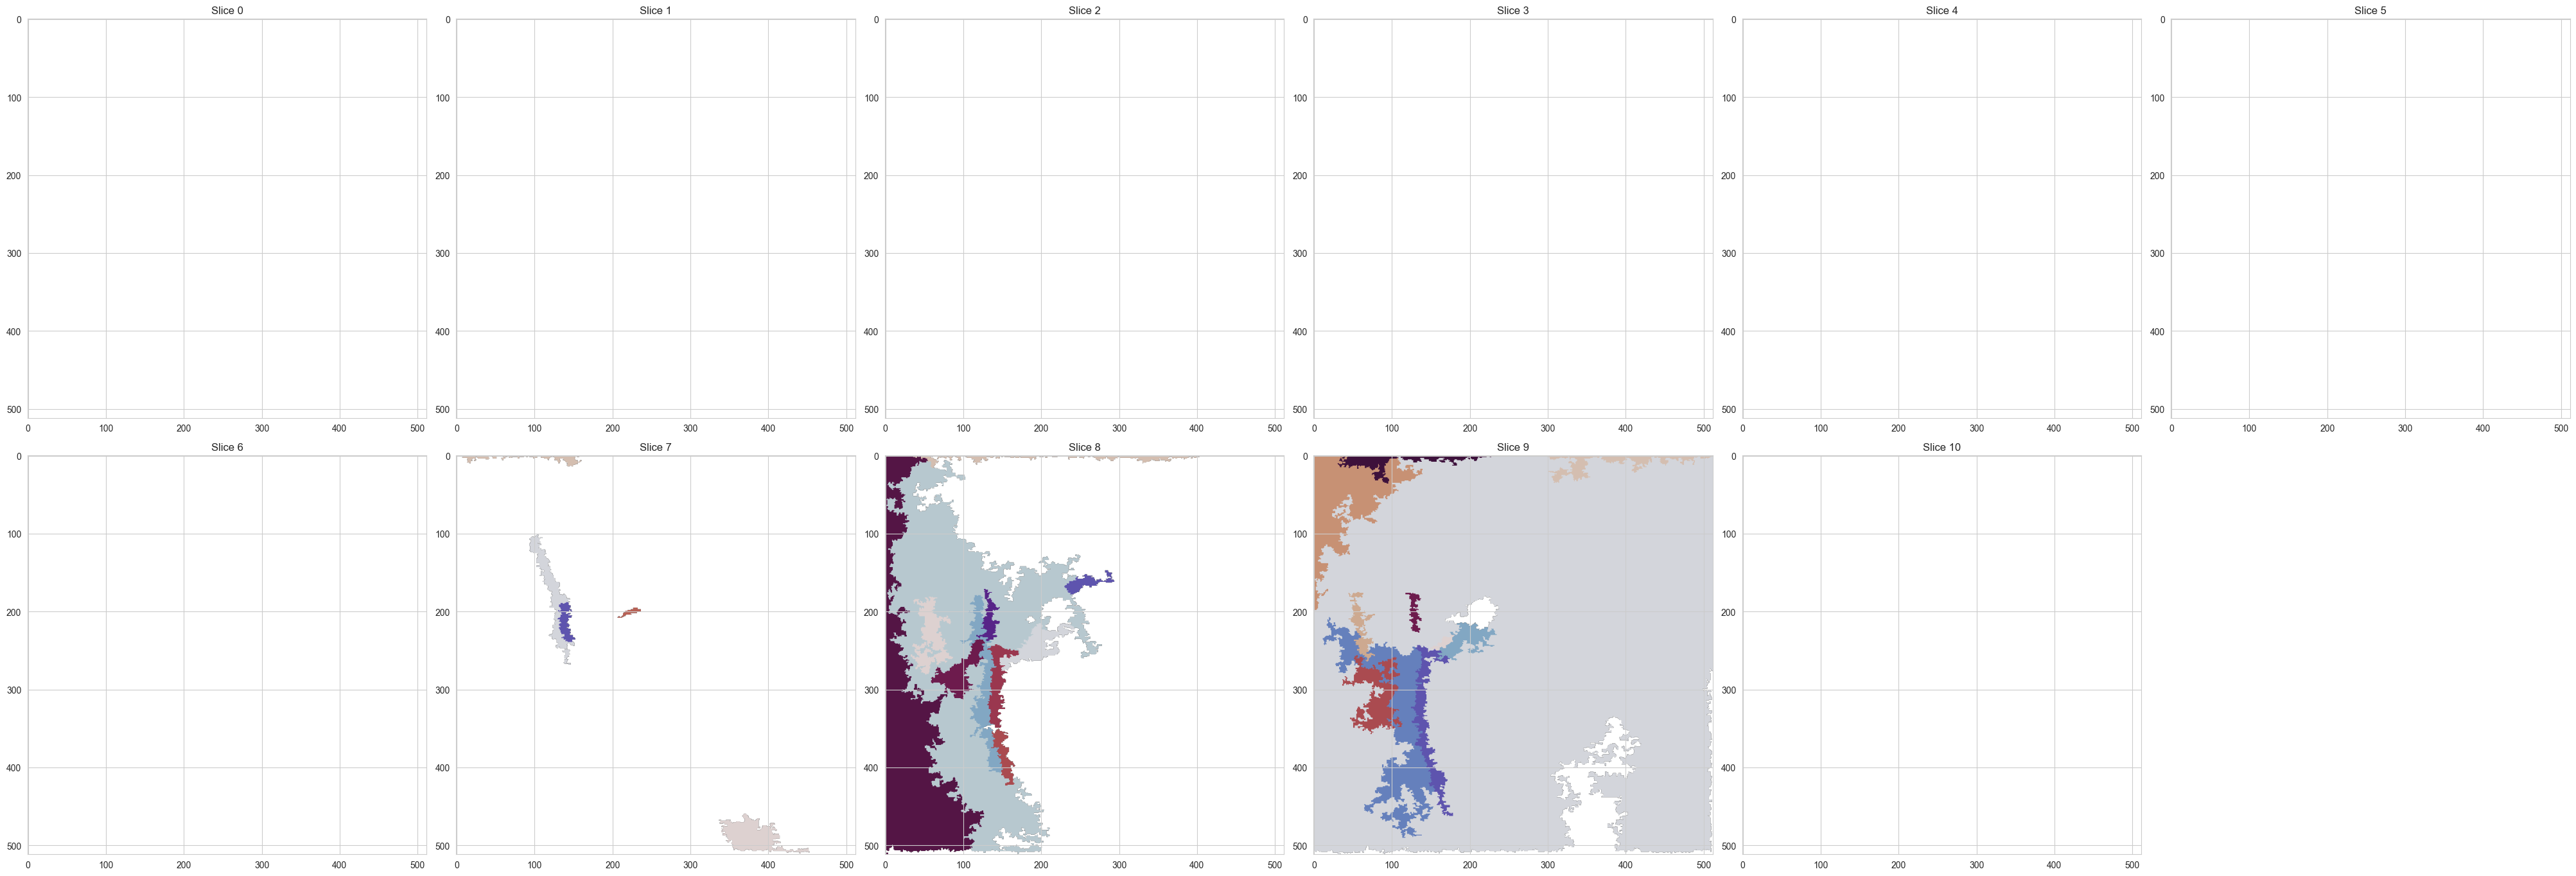

In [93]:
rois = []
for z in range(7, 10):
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for idx, v in enumerate(values):
        if v == 6:
            rois.append([z,idx])

print(rois)
print(len(rois))
plot_spatial_location(rois, cluster_labels, DIMENSIONS)

9


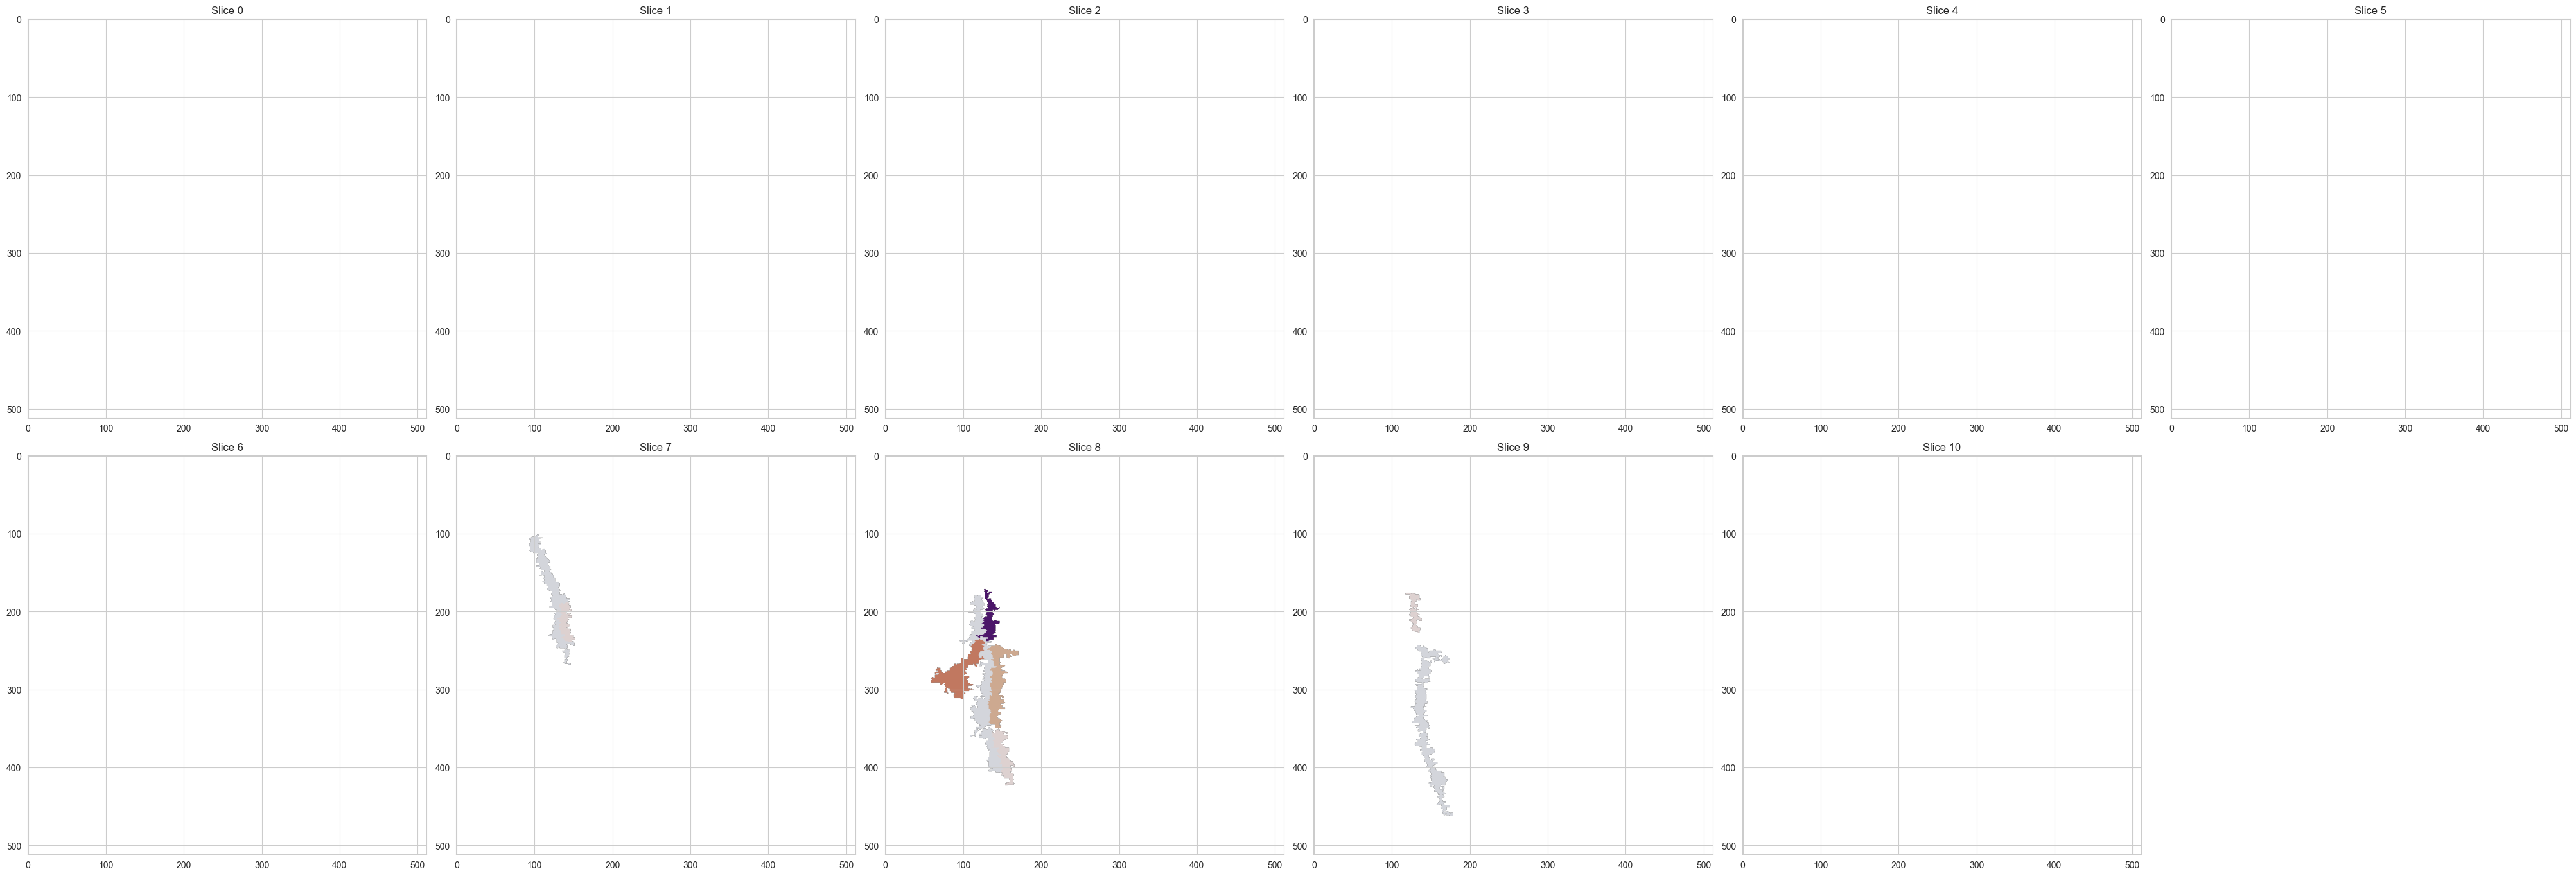

In [100]:
pip_rois = [rois[0], rois[1], rois[7], rois[13], rois[9], rois[11], rois[12], rois[19], rois[21]]
print(len(pip_rois))
plot_spatial_location(pip_rois, cluster_labels, DIMENSIONS)

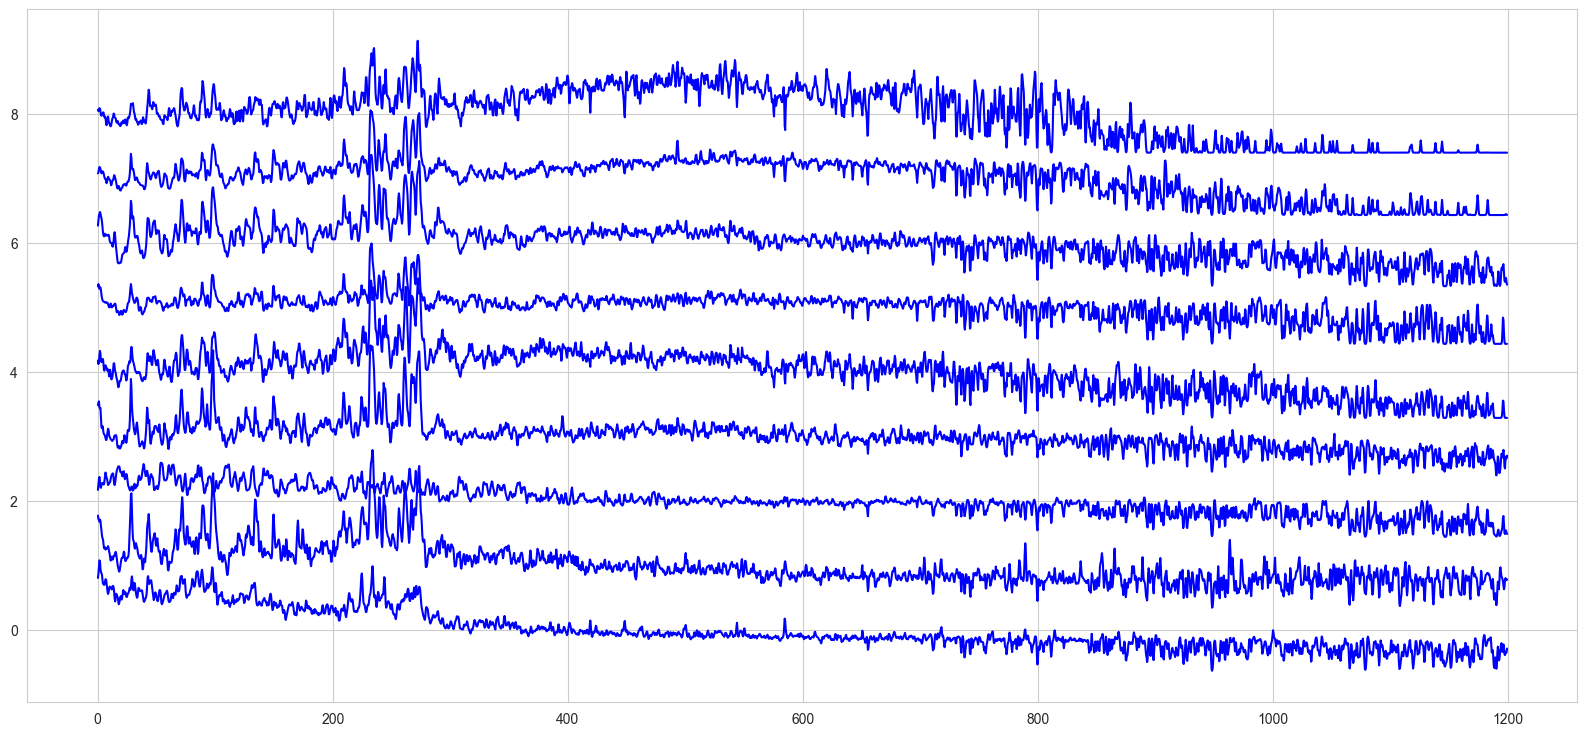

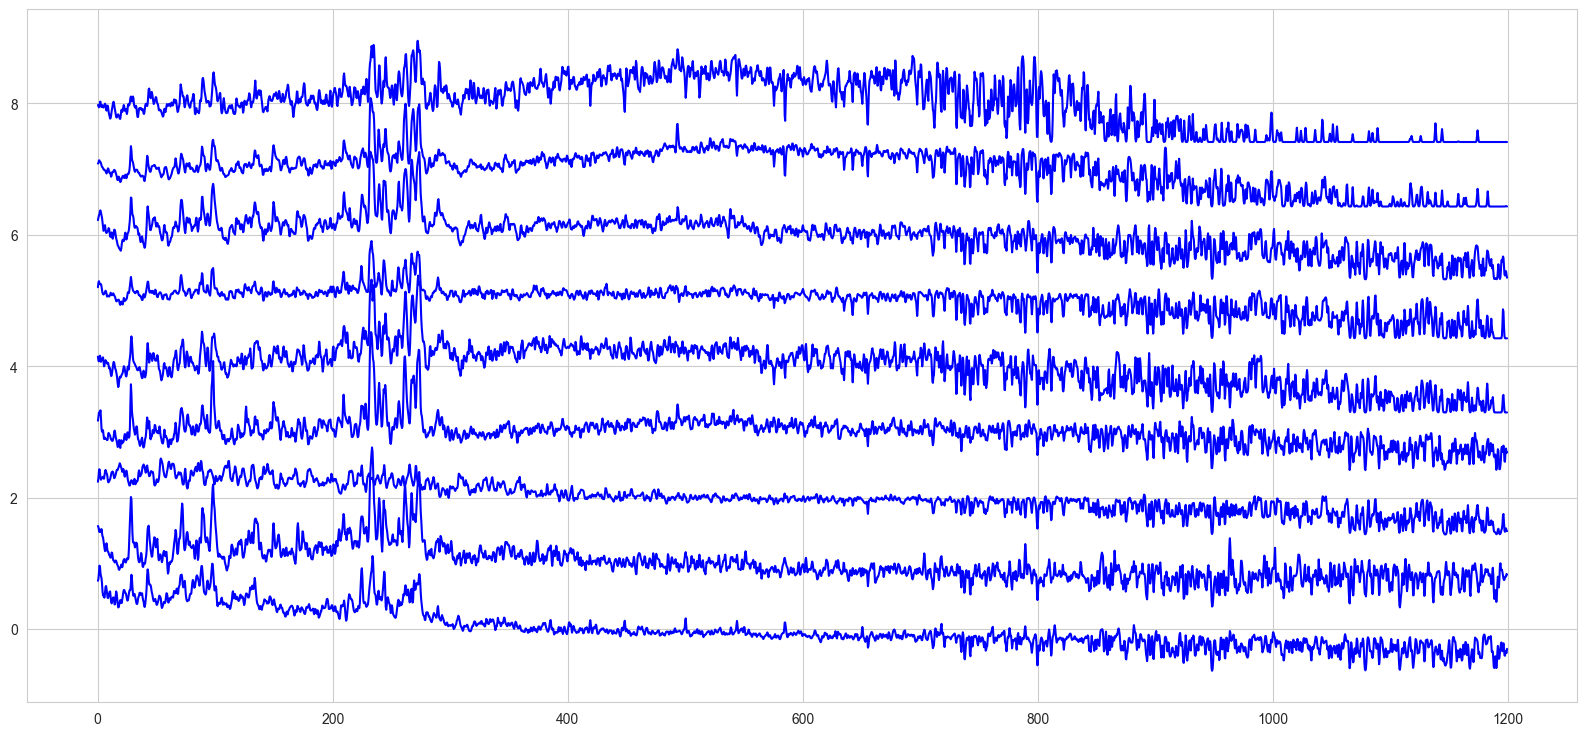

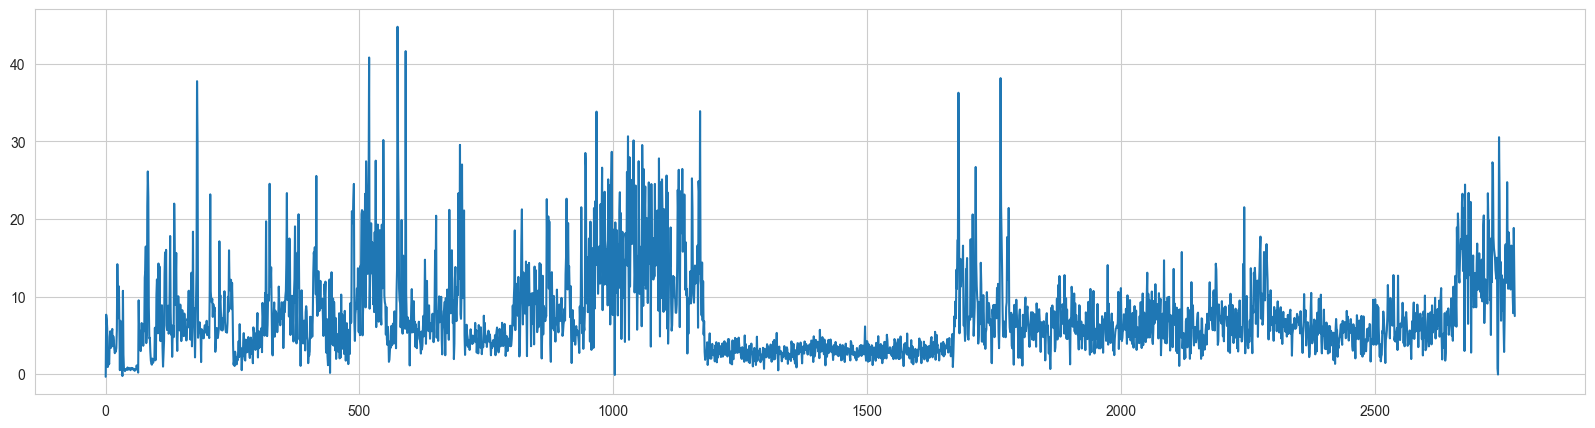

In [101]:
plot_zscored_activity(pip_rois, signal_xr)
plot_zscored_activity(pip_rois, sh_signal_xr)
plt.figure(figsize=(20,5))
plt.plot(synced_walk_speeds)

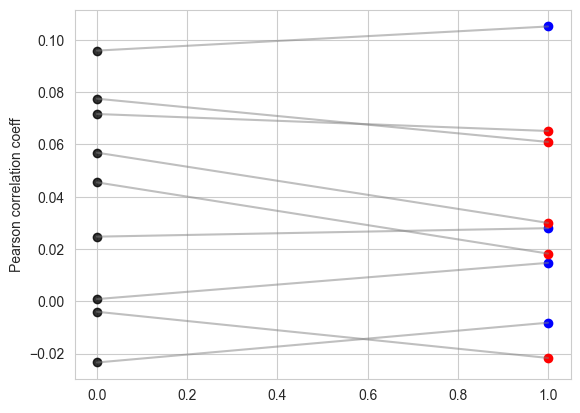

In [102]:
# plot where x is z-poss, y is correlation
correlation = xr.corr(signal_xr, behav_xr, dim='time')
sh_correlation = xr.corr(sh_signal_xr, behav_xr, dim='time')

for pip in pip_rois:
    to_plot = correlation.isel(zposs=pip[0], roi=pip[1])
    to_plot_sh = sh_correlation.isel(zposs=pip[0], roi=pip[1])
    plt.plot([0,1], [to_plot, to_plot_sh], color='gray', alpha=0.5)
    plt.scatter(0, to_plot, color='black', alpha=0.8)
    if to_plot_sh < to_plot:
        color = 'red'
    else:
        color = 'blue'
    plt.scatter(1, to_plot_sh, color=color, alpha=1)
    plt.ylabel('Pearson correlation coeff')

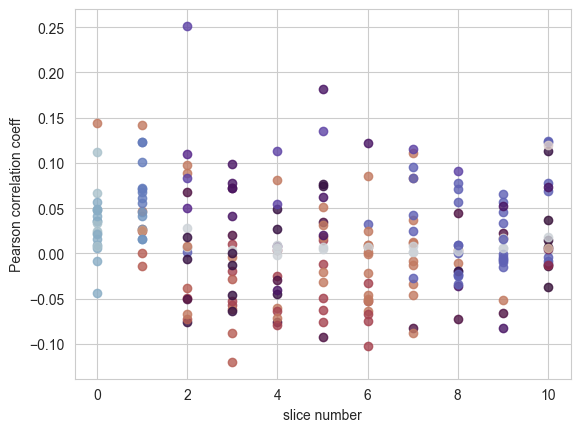

In [37]:
# plot where x is z-poss, y is correlation
correlation = xr.corr(signal_xr, behav_xr, dim='time')
sh_correlation = xr.corr(sh_signal_xr, behav_xr, dim='time')

for iSlice in range(0 ,signal_xr['zposs'].max().item()+1):
    to_plot = correlation.isel(zposs=iSlice)
    for i, corrs in enumerate(to_plot):

        # if [iSlice, i] in rois:
        #     # plot pIP10 supervoxels in blue
        #     iCorr = correlation.isel(zposs=iSlice, roi=i)
        #
        #     plt.scatter(iSlice, iCorr, color='b')
        # else:
        #     # plot non-pIP10 supervoxels in gray
        #     plt.scatter(iSlice, corrs, color='gray', alpha=0.5)

        label = grouped_sv.supervoxel.sel(zposs=iSlice, roi=i).cluster.item()
        color = palette_colors[label-1]
        plt.scatter(iSlice, corrs, color=color, alpha=0.8)
        plt.xlabel('slice number')
        plt.ylabel('Pearson correlation coeff')
        # to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])

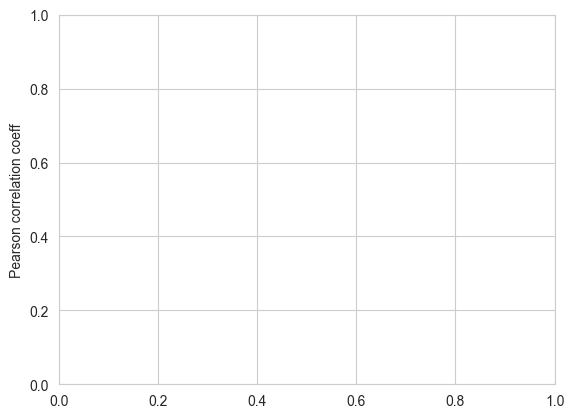

In [39]:
for iSlice in range(0 ,signal_xr['zposs'].max().item()+1):
    to_plot = correlation.isel(zposs=iSlice)
    to_plot_sh = sh_correlation.isel(zposs=iSlice)
    for i, corrs in enumerate(to_plot):
        label = grouped_sv.supervoxel.sel(zposs=iSlice, roi=i).cluster.item()
        if label == 3 and 3<iSlice<7:
            plt.plot([0,1], [to_plot[i], to_plot_sh[i]], color='gray', alpha=0.5)
            plt.scatter(0, to_plot[i], color='blue', alpha=0.8)
            plt.scatter(1, to_plot_sh[i], color='gray', alpha=1)
        plt.ylabel('Pearson correlation coeff')

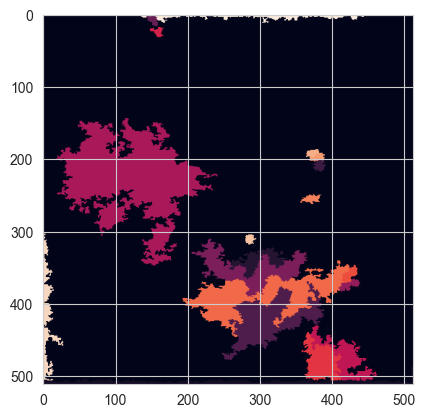

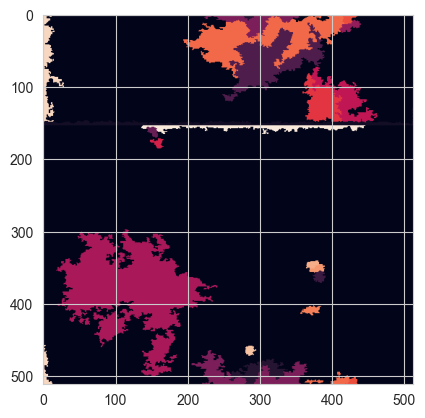

In [40]:
rng = np.random.default_rng()
xs, ys = rng.integers(low=-102, high=102, size=[2])
shifted_labels = np.roll(cluster_labels, shift=[xs, ys], axis=1)

r = np.reshape(cluster_labels, [-1,512,512])
w = np.reshape(shifted_labels, [-1,512,512])

plt.imshow(r[5].T)
plt.figure()
plt.imshow(w[5].T)